# IMU 정지 샘플 시각화 — 단일 샘플 magnitude 로 raw accel vs linear 판별

**핵심 논리:** linear accel(중력 제거)이면 정지 시 `|accel| ≈ 0`, raw accel(중력 포함)이면 `|accel| ≈ 1g`.
두 값의 차이(1g)는 센서 노이즈(수십 mg)보다 압도적으로 커서 **확실히 정지 상태인 샘플 하나의 magnitude만 봐도** 판별이 끝난다 — 수많은 샘플을 평균낼 필요가 없다.

**그래서 할 일:**
1. 각 디바이스 세션의 **앞부분**을 그래프로 그려, XYZ 축이 평탄(변화≈0)한 **정지 구간**을 눈으로 확정한다.
2. 그 정지 구간 안의 **고유 샘플 하나**의 `|accel|` 을 읽는다 → 0 근처면 linear, 1g 근처면 raw.

**주의 (고유 샘플):** parquet 은 원본이 아니라 업샘플(보간)된 값이다(samsung1≈1925Hz, samsung2=2000Hz).
보간으로 만들어진 가짜 값을 피하려고 **원본 레이트(samsung1=148Hz / samsung2=66Hz)** 기준 stride 로 고유 샘플만 뽑아 점으로 표시한다.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 폰트 (모듈명: koreanize_matplotlib)

ROOT = os.path.abspath('..')

# 양쪽 디바이스 모두 triceps IMU 만 사용 (samsung1 parquet 에 biceps_* 가 남아있어도 미사용)
SRC = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung1.parquet'),
                      columns=['triceps_X','triceps_Y','triceps_Z',
                               'filename','timestamp','subject'])
TGT = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung2_original.parquet'),
                      columns=['triceps_X','triceps_Y','triceps_Z',
                               'csv_filename_l','Index_Time','subject_id'])

# (label, df, IMU 3축, 세션컬럼, 시간컬럼, 원본레이트Hz, 단위)
SPECS = [
    ('samsung1 · triceps',          SRC, ['triceps_X','triceps_Y','triceps_Z'], 'filename',       'timestamp',  148, 'g'),
    ('samsung2_original · triceps', TGT, ['triceps_X','triceps_Y','triceps_Z'], 'csv_filename_l', 'Index_Time',  66, 'milli-g'),
]
print('loaded | samsung1:', SRC.shape, '| samsung2_original:', TGT.shape)

loaded | samsung1: (16148132, 6) | samsung2_original: (26224560, 6)


In [2]:
def original_samples(g, cols, time, orig_fs):
    '''업샘플된 행에서 원본 레이트(orig_fs)의 고유 샘플만 시간-stride 로 추출.
    반환: (t0 기준 상대시각, accel 3축 배열, 업샘플레이트, stride)'''
    t  = g[time].to_numpy(np.float64)
    dt = np.median(np.diff(t))
    fs_up  = 1.0 / dt
    stride = max(1, int(round(fs_up / orig_fs)))
    sel = slice(0, None, stride)
    return t[sel] - t[sel][0], g[cols].to_numpy(np.float64)[sel], fs_up, stride


def rest_sample(t, A, rest_sec):
    '''앞 rest_sec초(정지 후보) 안에서 대표 샘플 하나(magnitude 중앙값)를 고른다.
    반환: (단일샘플 |accel|, 그 샘플 3축벡터, 후보구간 축별 std[정지 확정용])'''
    win  = t <= rest_sec
    Aw   = A[win]
    mags = np.sqrt((Aw ** 2).sum(1))
    i    = np.argsort(mags)[len(mags) // 2]   # 중앙값 magnitude 샘플 1개
    return float(mags[i]), Aw[i], Aw.std(0)

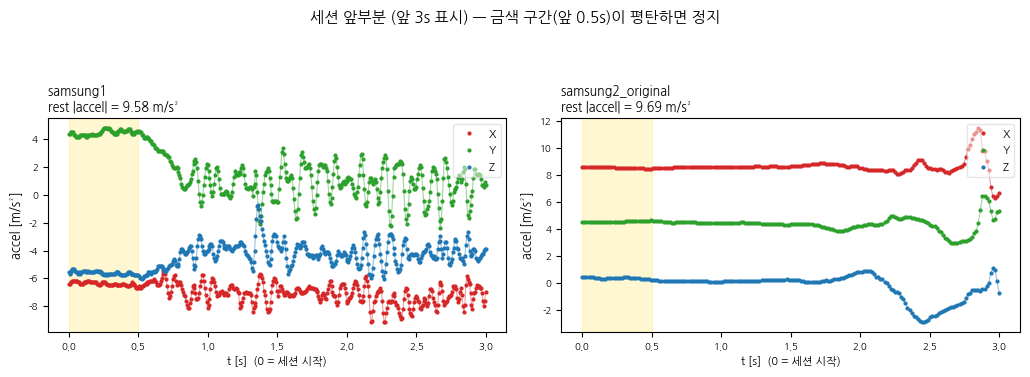

In [3]:
# 정지 샘플 시각화 — 금색 구간(앞 REST_SEC초)이 평탄하면 정지 확정, 그 안 고유 샘플 1개 |accel| 로 판별.
T_VIEW   = 3.0     # 앞부분 표시 길이 [초]   ← 하이퍼파라미터(제목에 자동 반영)
REST_SEC = 0.5    # 정지 후보 구간 [초]     ← 하이퍼파라미터(제목에 자동 반영)
COL      = {'X':'tab:red', 'Y':'tab:green', 'Z':'tab:blue'}
G_MS2    = 9.80665   # 1 g = 9.80665 m/s² (가속도 단위로 환산)

# (SPECS 인덱스, 보여줄 세션 번호) — samsung1=세션1, samsung2=세션2 만 표시
PICK = [(0, 1), (1, 9)]

fig, axes = plt.subplots(1, len(PICK), figsize=(5.2 * len(PICK), 3.8), squeeze=False)
for j, (si, sj) in enumerate(PICK):
    label, df, cols, sess, time, orig_fs, unit = SPECS[si]
    dev = label.split(' · ')[0]                       # 'triceps' 레이블 제거 → 디바이스명만
    g_scale = 1000.0 if unit == 'milli-g' else 1.0
    sid = df[sess].drop_duplicates().to_numpy()[sj]
    g   = df[df[sess] == sid].sort_values(time)
    t, A, fs_up, stride = original_samples(g, cols, time, orig_fs)
    A   = A * (G_MS2 / g_scale)                       # g/milli-g → m/s² 로 통일 (samsung2 는 /1000 후 환산)
    v   = t <= T_VIEW
    tv, Av = t[v], A[v]
    ax = axes[0][j]
    for k, axis in enumerate(['X', 'Y', 'Z']):
        ax.plot(tv, Av[:, k], '-', color=COL[axis], lw=0.8, alpha=0.45)
        ax.plot(tv, Av[:, k], '.', color=COL[axis], ms=4, label=axis)
    mag1, _, _ = rest_sample(tv, Av, REST_SEC)
    ax.axvspan(0, REST_SEC, color='gold', alpha=0.18)
    ax.set_title(f'{dev} \nrest |accel| = {mag1:.2f} m/s²', fontsize=9, loc='left')
    ax.set_xlabel('t [s]  (0 = 세션 시작)', fontsize=8)
    ax.set_ylabel('accel [m/s²]', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=8, loc='upper right', ncol=1, framealpha=0.5)
fig.suptitle(f'세션 앞부분 (앞 {T_VIEW:g}s 표시) — 금색 구간(앞 {REST_SEC:g}s)이 평탄하면 정지', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

## 해석

- **금색 구간(정지 후보)에서 XYZ 가 평탄하면** 그 구간은 실제 정지 상태 → 그래프만으로 확정.
- 그 정지 구간에서 **고유 샘플 단 하나**의 `|accel|` 이:
  - **0 근처** → linear accel (중력 제거됨)
  - **~1g 근처** → raw accel (중력 포함) ← 정렬 가능
- 관측: samsung1 ≈ 0.9~1.0 g, samsung2 ≈ 0.9~1.0 g → 0 이 아니라 ~1g → **중력 포함 raw accelerometer**, gravity alignment 가능.
- **참고(이전 결론 수정):** 예전 "samsung1 ≈ 0.65 g · 스케일 문제" 는 **운동 구간까지 섞어 `|accel|` 을 평균낸 artifact** 였다.
  정지 샘플 하나만 제대로 보면 **~0.95 g 로 거의 1g**. (잔여 스케일 차이는 방향 정렬·z-score 라 무해.)